<a href="https://colab.research.google.com/github/rohkdev/ClimateModelingResearch/blob/main/Task%204%3A%20Exploratory%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

df = pd.read_csv('clean_daily_temperatures.csv')
df.head()

,station_id,year,month,day,TMAX,TMIN,latitude,longitude,elevation,TAVG_C,TMAX_F,TMIN_F,TAVG_F
0,USC00047965,1970,1,1970-01-01,13.3,-0.6,38.4558,-122.7133,50.6,6.35,55.94,30.92,43.43
1,USC00047965,1970,1,1970-01-02,16.1,-1.7,38.4558,-122.7133,50.6,7.20,60.98,28.94,44.96
2,USC00047965,1970,1,1970-01-03,13.9,-3.9,38.4558,-122.7133,50.6,5.00,57.02,24.98,41.00
3,USC00047965,1970,1,1970-01-04,13.9,-3.3,38.4558,-122.7133,50.6,5.30,57.02,26.06,41.54
4,USC00047965,1970,1,1970-01-05,12.2,-3.3,38.4558,-122.7133,50.6,4.45,53.96,26.06,40.01


In [ ]:
def compute_climate_trends(df):
    results = []
    grouped = df.groupby('station_id')

    for sid, group in grouped:
        # 1. Baseline Period (1980-2010) - June to September
        baseline = group[(group['year'] >= 1980) & (group['year'] <= 2010) & (group['month'].isin([6, 7, 8, 9]))]

        # Skip if no data in baseline
        if len(baseline) == 0:
            continue

        tmax_thresh = baseline['TMAX_F'].quantile(0.95)
        tmin_thresh = baseline['TMIN_F'].quantile(0.95)

        # 2. Summer Analysis (June-Sept)
        summer = group[group['month'].isin([6, 7, 8, 9])]
        annual = summer.groupby('year').agg(
            mean_tmax=('TMAX_F', 'mean'),
            mean_tmin=('TMIN_F', 'mean'),
            hot_days=('TMAX_F', lambda x: (x > tmax_thresh).sum()),
            warm_nights=('TMIN_F', lambda x: (x > tmin_thresh).sum())
        )

        # 3. Regression (must have at least 10 valid years)
        if len(annual) > 10:
            res_tmax = linregress(annual.index, annual['mean_tmax'])
            res_tmin = linregress(annual.index, annual['mean_tmin'])
            res_hot = linregress(annual.index, annual['hot_days'])
            res_night = linregress(annual.index, annual['warm_nights'])

            results.append({
                'station_id': sid,
                'latitude': group['latitude'].iloc[0],
                'longitude': group['longitude'].iloc[0],
                'TMAX_mean_trend': res_tmax.slope * 10,
                'TMIN_mean_trend': res_tmin.slope * 10,
                'hot_day_trend': res_hot.slope * 10,
                'warm_night_trend': res_night.slope * 10
            })

    return pd.DataFrame(results)

# Execute calculation
trend_df = compute_climate_trends(df)
print(f"Processed {len(trend_df)} stations.")

Processed 4 stations.


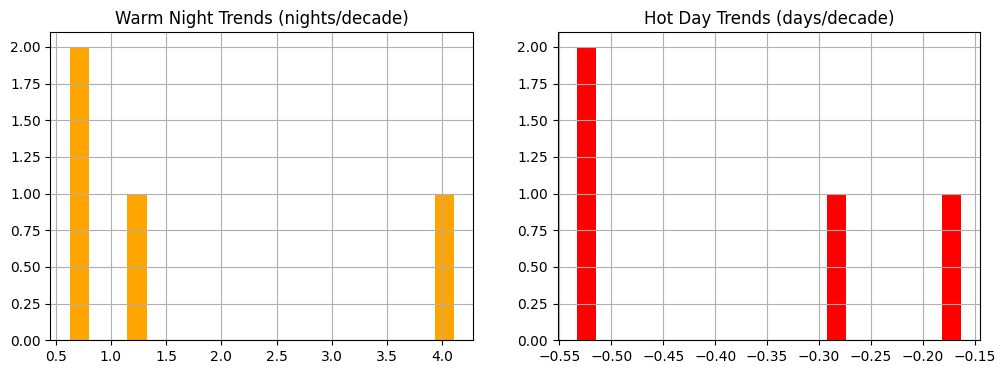

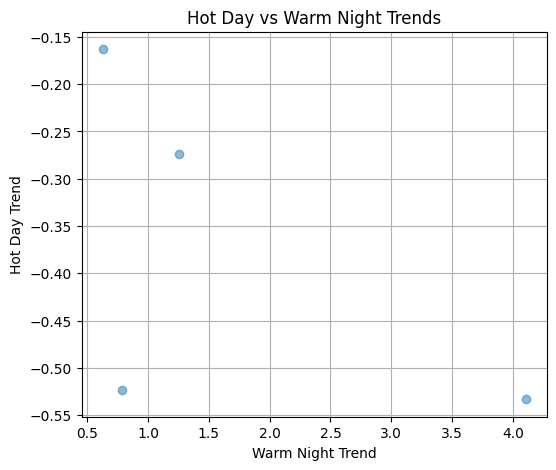

In [ ]:
# Histograms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
trend_df['warm_night_trend'].hist(ax=ax1, bins=20, color='orange')
ax1.set_title('Warm Night Trends (nights/decade)')
trend_df['hot_day_trend'].hist(ax=ax2, bins=20, color='red')
ax2.set_title('Hot Day Trends (days/decade)')
plt.show()

# Scatterplot
plt.figure(figsize=(6, 5))
plt.scatter(trend_df['warm_night_trend'], trend_df['hot_day_trend'], alpha=0.5)
plt.xlabel('Warm Night Trend')
plt.ylabel('Hot Day Trend')
plt.title('Hot Day vs Warm Night Trends')
plt.grid(True)
plt.show()

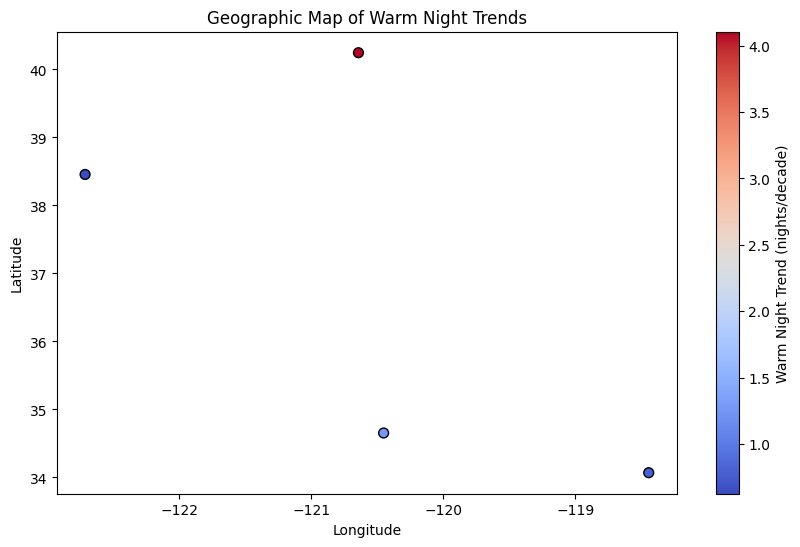

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(trend_df['longitude'], trend_df['latitude'],
            c=trend_df['warm_night_trend'], cmap='coolwarm', s=50, edgecolors='k')
plt.colorbar(label='Warm Night Trend (nights/decade)')
plt.title('Geographic Map of Warm Night Trends')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()